# Семантическая сегментация LiDAR облаков точек

Проект по семантической сегментации промышленных LiDAR-сцен.
Архитектура: PointNet++. Фреймворк: PyTorch + PyTorch Geometric.

## Порядок выполнения

1. Установка зависимостей и подключение Drive
2. Константы и пути
3. Сплит датасета по circles
4. Dataset, модель PointNet++, метрики
5. Обучение
6. Тестирование и финальные метрики
7. Графики и confusion matrix

## 1. Установка зависимостей и подключение Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q plyfile torch-geometric
!pip install -q torch-scatter torch-cluster -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)")+cu121.html

import os, sys, json, glob, random, time, gc, shutil
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import fps, radius, knn_interpolate, PointNetConv

print("Torch:", torch.__version__, "CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU!")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


KeyboardInterrupt: 

In [2]:
import torch
print("Torch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU available:", torch.cuda.is_available())

Torch: 2.11.0+cu128
CUDA: 12.8
GPU available: True


In [3]:
import torch
torch_ver = torch.__version__.split('+')[0]
print(f"Torch version: {torch_ver}")

!pip install -q plyfile

for cu in ['cu128', 'cu124', 'cu121']:
    url = f"https://data.pyg.org/whl/torch-{torch_ver}+{cu}.html"
    print(f"\nTrying {cu}...")
    result = !pip install -q torch-scatter torch-cluster -f {url} 2>&1 | tail -5
    print('\n'.join(result))
    try:
        import torch_scatter, torch_cluster
        print(f"OK with {cu}!")
        break
    except ImportError:
        pass

!pip install -q torch-geometric

import torch_geometric
from torch_geometric.nn import fps, radius, knn_interpolate, PointNetConv
print(f"\ntorch_geometric: {torch_geometric.__version__}")
print("All imports OK")

Torch version: 2.11.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.7 MB/s eta 0:00:00

Trying cu128...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 108.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 117.8 MB/s eta 0:00:00
OK with cu128!
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.4 MB/s eta 0:00:00

torch_geometric: 2.7.0
All imports OK


In [ ]:
import os
os._exit(0)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, json, glob, random, time, gc, shutil
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import fps, radius, knn_interpolate, PointNetConv

print("Torch:", torch.__version__, "CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU!")
print("torch_geometric: OK")

Mounted at /content/drive
Torch: 2.11.0+cu128 CUDA: True
GPU: Tesla T4
torch_geometric: OK


## 2. Константы и пути

In [5]:
DATA_ROOT     = Path('/content/drive/MyDrive/IS')
DRIVE_PROJECT = Path('/content/drive/MyDrive/IS_project')
CACHE_ROOT    = DRIVE_PROJECT / 'cache_npz'
MY_RESULTS    = Path('/content/drive/MyDrive/IS_project_results')

for sd in ['configs','checkpoints','logs','figures','results','splits']:
    (MY_RESULTS / sd).mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [
    'unknown','pipe','wire','wall','floor','ceiling','machine','desk','rack',
    'boiler','conveyor','structure','infrastructure','roof','window','door',
    'gate','terrain','facade'
]
NUM_CLASSES = len(CLASS_NAMES)

ACTIVE_IDS  = [0,1,2,3,4,5,6,7,8,9,11,12]
N_CLASSES   = len(ACTIVE_IDS)
OLD2NEW     = {old: new for new, old in enumerate(ACTIVE_IDS)}
NEW2NAME    = {new: CLASS_NAMES[old] for new, old in enumerate(ACTIVE_IDS)}
CLASS_WEIGHTS = torch.tensor([1.191,0.801,2.521,0.380,0.224,0.181,0.796,0.774,0.715,1.627,0.599,2.191], dtype=torch.float32)

print(f"Cache files: {len(list(CACHE_ROOT.rglob('*.npz')))}")
print(f"N_CLASSES: {N_CLASSES}")
print(f"Results dir: {MY_RESULTS}")
print(f"Class names: {[NEW2NAME[i] for i in range(N_CLASSES)]}")

Cache files: 711
N_CLASSES: 12
Results dir: /content/drive/MyDrive/IS_project_results
Class names: ['unknown', 'pipe', 'wire', 'wall', 'floor', 'ceiling', 'machine', 'desk', 'rack', 'boiler', 'structure', 'infrastructure']


In [6]:
print("IS exists:           ", DATA_ROOT.exists())
print("IS_project exists:   ", DRIVE_PROJECT.exists())
print("Cache files:         ", len(list(CACHE_ROOT.rglob('*.npz'))))
print("Results dir writable:", os.access(MY_RESULTS, os.W_OK))

IS exists:            True
IS_project exists:    True
Cache files:          711
Results dir writable: True


## 3. Сплит по circles

Делим внутри каждой сцены по проходам сканера (circles): первые N-2 в train,
предпоследний в val, последний в test. Без утечек, без смешивания проходов.

In [7]:
all_npz = sorted(CACHE_ROOT.rglob('*.npz'))
scene_circle = defaultdict(lambda: defaultdict(list))
for p in all_npz:
    parts = p.relative_to(CACHE_ROOT).parts
    scene_circle[parts[0]][parts[1]].append(str(p))

train_files, val_files, test_files = [], [], []
for scene, circles in sorted(scene_circle.items()):
    sorted_circles = sorted(circles.keys())
    n = len(sorted_circles)
    for i, circle in enumerate(sorted_circles):
        files = sorted(circles[circle])
        if i < n - 2:    train_files += files
        elif i == n - 2: val_files   += files
        else:            test_files  += files

print(f"Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

with open(MY_RESULTS / 'splits' / 'split_v2.json', 'w') as f:
    json.dump({'train': train_files, 'val': val_files, 'test': test_files}, f, indent=2)
print(f"Split saved to {MY_RESULTS / 'splits' / 'split_v2.json'}")

Train: 419, Val: 160, Test: 132
Split saved to /content/drive/MyDrive/IS_project_results/splits/split_v2.json


## 4. Dataset, модель PointNet++, метрики

In [8]:
N_POINTS = 24576

def load_npz(path):
    d = np.load(path)
    return d['xyz'].astype(np.float32), d['label'].astype(np.int32)

def remap_labels(lab, old2new):
    out = np.full_like(lab, -1)
    for old, new in old2new.items():
        out[lab == old] = new
    return out

def normalize_xyz(xyz):
    xyz = xyz - xyz.mean(axis=0)
    scale = np.abs(xyz).max()
    return xyz / scale if scale > 0 else xyz

def augment(xyz):
    angle = np.random.uniform(0, 2*np.pi)
    c, s = np.cos(angle), np.sin(angle)
    R = np.array([[c,-s,0],[s,c,0],[0,0,1]], dtype=np.float32)
    xyz = xyz @ R.T
    xyz += np.random.uniform(-0.05, 0.05, size=(1,3)).astype(np.float32)
    xyz *= np.random.uniform(0.9, 1.1)
    xyz += np.random.normal(0, 0.005, size=xyz.shape).astype(np.float32)
    return xyz

class PointCloudDataset(Dataset):
    def __init__(self, files, n_points=N_POINTS, do_aug=False):
        self.files, self.n_points, self.do_aug = files, n_points, do_aug
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        xyz, lab = load_npz(self.files[idx])
        lab = remap_labels(lab, OLD2NEW)
        valid = lab >= 0
        xyz, lab = xyz[valid], lab[valid]
        n = len(xyz)
        choice = np.random.choice(n, self.n_points, replace=(n < self.n_points))
        xyz, lab = xyz[choice], lab[choice]
        xyz = normalize_xyz(xyz)
        if self.do_aug:
            xyz = augment(xyz)
        return torch.from_numpy(xyz), torch.from_numpy(lab).long()

def collate_fn(batch):
    pos_list, lab_list, batch_idx = [], [], []
    for i, (xyz, lab) in enumerate(batch):
        pos_list.append(xyz)
        lab_list.append(lab)
        batch_idx.append(torch.full((len(xyz),), i, dtype=torch.long))
    return torch.cat(pos_list), torch.cat(lab_list), torch.cat(batch_idx)

class SetAbstraction(nn.Module):
    def __init__(self, ratio, r, in_ch, out_ch):
        super().__init__()
        self.ratio, self.r = ratio, r
        self.conv = PointNetConv(nn.Sequential(
            nn.Linear(in_ch+3, out_ch), nn.BatchNorm1d(out_ch), nn.ReLU(),
            nn.Linear(out_ch, out_ch),  nn.BatchNorm1d(out_ch), nn.ReLU(),
        ), add_self_loops=False)
    def forward(self, x, pos, batch):
        idx = fps(pos, batch, ratio=self.ratio)
        row, col = radius(pos, pos[idx], self.r, batch, batch[idx], max_num_neighbors=64)
        edge_index = torch.stack([col, row], dim=0)
        x_dst = None if x is None else x[idx]
        return self.conv((x, x_dst), (pos, pos[idx]), edge_index), pos[idx], batch[idx]

class FP(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_ch+skip_ch, out_ch), nn.BatchNorm1d(out_ch), nn.ReLU(),
            nn.Linear(out_ch, out_ch), nn.BatchNorm1d(out_ch), nn.ReLU(),
        )
    def forward(self, x, pos, batch, x_skip, pos_skip, batch_skip):
        x_interp = knn_interpolate(x, pos, pos_skip, batch, batch_skip, k=3)
        x_cat = torch.cat([x_interp, x_skip], dim=1) if x_skip is not None else x_interp
        return self.mlp(x_cat)

class PointNetPP(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.sa1 = SetAbstraction(0.25, 0.1, 0,   64)
        self.sa2 = SetAbstraction(0.25, 0.2, 64,  128)
        self.sa3 = SetAbstraction(0.25, 0.4, 128, 256)
        self.fp3 = FP(256, 128, 256)
        self.fp2 = FP(256, 64,  128)
        self.fp1 = FP(128, 0,   128)
        self.head = nn.Sequential(
            nn.Linear(128,128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(128, n_classes))
    def forward(self, pos, batch):
        x1, p1, b1 = self.sa1(None, pos, batch)
        x2, p2, b2 = self.sa2(x1, p1, b1)
        x3, p3, b3 = self.sa3(x2, p2, b2)
        x = self.fp3(x3, p3, b3, x2, p2, b2)
        x = self.fp2(x, p2, b2, x1, p1, b1)
        x = self.fp1(x, p1, b1, None, pos, batch)
        return self.head(x)

def compute_metrics(preds, labels, n_classes):
    preds = np.concatenate(preds)
    labels = np.concatenate(labels)
    mask = labels >= 0
    p, l = preds[mask], labels[mask]
    oa = (p == l).mean()
    ious, f1s = [], []
    for c in range(n_classes):
        tp = ((p==c)&(l==c)).sum()
        fp = ((p==c)&(l!=c)).sum()
        fn = ((p!=c)&(l==c)).sum()
        if tp+fp+fn == 0:
            ious.append(float('nan'))
            f1s.append(float('nan'))
        else:
            ious.append(tp/(tp+fp+fn))
            prec = tp/(tp+fp) if tp+fp>0 else 0
            rec  = tp/(tp+fn) if tp+fn>0 else 0
            f1s.append(2*prec*rec/(prec+rec) if prec+rec>0 else 0)
    return {
        'oa': float(oa),
        'miou': float(np.nanmean(ious)),
        'macro_f1': float(np.nanmean(f1s)),
        'iou_per_class': ious,
        'f1_per_class': f1s,
    }

device = torch.device('cuda')
model = PointNetPP(N_CLASSES).to(device)
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

Params: 406,348


## 5. Обучение

40 эпох с косинусным расписанием learning rate. Чекпойнт лучшей модели по val mIoU
сохраняется на Drive после каждого улучшения. Лог обучения тоже на Drive.

In [ ]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

train_ds = PointCloudDataset(train_files, do_aug=True)
val_ds   = PointCloudDataset(val_files,   do_aug=False)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True,  num_workers=2, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=2, shuffle=False, num_workers=2, collate_fn=collate_fn, pin_memory=True)

N_EPOCHS = 40
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-5)
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.to(device), ignore_index=-1)

CKPT     = MY_RESULTS / 'checkpoints' / 'best_model.pth'
LOG_PATH = MY_RESULTS / 'logs' / 'train_log.json'

best_miou = 0
log = []
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}")
print(f"{'Ep':>3} {'TrLoss':>8} {'TrOA':>7} {'TrmIoU':>8} {'VaLoss':>8} {'VaOA':>7} {'VamIoU':>8} {'Time':>6}")

for epoch in range(1, N_EPOCHS+1):
    t0 = time.time()
    model.train()
    tloss, tp_, tl_ = 0, [], []
    for pos, lab, bat in train_loader:
        pos, lab, bat = pos.to(device), lab.to(device), bat.to(device)
        optimizer.zero_grad()
        logits = model(pos, bat)
        loss = criterion(logits, lab)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tloss += loss.item()
        tp_.append(logits.argmax(1).cpu().numpy())
        tl_.append(lab.cpu().numpy())
    tr = compute_metrics(tp_, tl_, N_CLASSES)
    tr['loss'] = tloss/len(train_loader)

    model.eval()
    vloss, vp_, vl_ = 0, [], []
    with torch.no_grad():
        for pos, lab, bat in val_loader:
            pos, lab, bat = pos.to(device), lab.to(device), bat.to(device)
            logits = model(pos, bat)
            vloss += criterion(logits, lab).item()
            vp_.append(logits.argmax(1).cpu().numpy())
            vl_.append(lab.cpu().numpy())
    vl = compute_metrics(vp_, vl_, N_CLASSES)
    vl['loss'] = vloss/len(val_loader)

    scheduler.step()
    elapsed = time.time() - t0
    print(f"{epoch:>3}  {tr['loss']:>8.4f}  {tr['oa']:>7.4f}  {tr['miou']:>8.4f}  "
          f"{vl['loss']:>8.4f}  {vl['oa']:>7.4f}  {vl['miou']:>8.4f}  {elapsed:>5.0f}s")

    log.append({'epoch': epoch, 'train': tr, 'val': vl, 'lr': scheduler.get_last_lr()[0]})
    with open(LOG_PATH, 'w') as f:
        json.dump(log, f, indent=2)

    if vl['miou'] > best_miou:
        best_miou = vl['miou']
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'val_miou': best_miou,
        }, CKPT)
        print(f"    saved best model (val mIoU={best_miou:.4f}) to Drive")

print(f"\nDone. Best val mIoU: {best_miou:.4f}")

Train: 419  Val: 160
 Ep   TrLoss    TrOA   TrmIoU   VaLoss    VaOA   VamIoU   Time
  1    1.7349   0.5716    0.2127    1.7830   0.5573    0.1805    244s
    saved best model (val mIoU=0.1805) to Drive
  2    1.3373   0.7067    0.3359    1.7406   0.6072    0.2257    127s
    saved best model (val mIoU=0.2257) to Drive
  3    1.1961   0.7424    0.3778    1.2712   0.7146    0.3040    126s
    saved best model (val mIoU=0.3040) to Drive
  4    1.1029   0.7617    0.3971    1.2291   0.7362    0.3378    126s
    saved best model (val mIoU=0.3378) to Drive
  5    1.0125   0.7886    0.4215    1.0915   0.7665    0.3615    126s
    saved best model (val mIoU=0.3615) to Drive
  6    0.9235   0.8020    0.4390    1.3157   0.7161    0.3111    126s
  7    0.8819   0.8170    0.4594    1.2267   0.7340    0.3399    126s
  8    0.8021   0.8255    0.4727    1.3632   0.7467    0.3434    126s
  9    0.7784   0.8271    0.4824    1.2163   0.7760    0.3755    126s
    saved best model (val mIoU=0.3755) to Driv

In [9]:
from pathlib import Path

MY_RESULTS = Path('/content/drive/MyDrive/IS_project_results')
ckpt_path = MY_RESULTS / 'checkpoints' / 'best_model.pth'
log_path = MY_RESULTS / 'logs' / 'train_log.json'

print(f"Checkpoint exists: {ckpt_path.exists()}")
if ckpt_path.exists():
    print(f"  Size: {ckpt_path.stat().st_size / 1024:.1f} KB")
print(f"Log exists: {log_path.exists()}")
if log_path.exists():
    import json
    with open(log_path) as f:
        log = json.load(f)
    print(f"  Epochs logged: {len(log)}")
    print(f"  Best val mIoU: {max(e['val']['miou'] for e in log):.4f}")

Checkpoint exists: True
  Size: 1634.2 KB
Log exists: True
  Epochs logged: 30
  Best val mIoU: 0.4724


## 6. Тестирование

Загружаем лучший чекпойнт и оцениваем на test-сплите.
Считаем OA, Macro F1, mIoU и per-class метрики.

In [10]:
ckpt = torch.load(MY_RESULTS / 'checkpoints' / 'best_model.pth', map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']}, val mIoU={ckpt['val_miou']:.4f}")

test_ds = PointCloudDataset(test_files, do_aug=False)
test_loader = DataLoader(test_ds, batch_size=2, shuffle=False, num_workers=2, collate_fn=collate_fn, pin_memory=True)

all_preds, all_labels = [], []
with torch.no_grad():
    for pos, lab, bat in tqdm(test_loader, desc='Test'):
        pos, lab, bat = pos.to(device), lab.to(device), bat.to(device)
        logits = model(pos, bat)
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_labels.append(lab.cpu().numpy())

test_metrics = compute_metrics(all_preds, all_labels, N_CLASSES)
print(f"\n=== TEST RESULTS ===")
print(f"Overall Accuracy: {test_metrics['oa']:.4f}")
print(f"Macro F1:         {test_metrics['macro_f1']:.4f}")
print(f"Mean IoU:         {test_metrics['miou']:.4f}")
print(f"\nPer-class IoU:")
for i, iou in enumerate(test_metrics['iou_per_class']):
    if not np.isnan(iou):
        print(f"  {NEW2NAME[i]:14s}  IoU={iou:.4f}  F1={test_metrics['f1_per_class'][i]:.4f}")

with open(MY_RESULTS / 'results' / 'test_metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=2)
print(f"\nSaved: {MY_RESULTS / 'results' / 'test_metrics.json'}")

Loaded checkpoint from epoch 22, val mIoU=0.4724


Test:   0%|          | 0/66 [00:00<?, ?it/s]


=== TEST RESULTS ===
Overall Accuracy: 0.8514
Macro F1:         0.5889
Mean IoU:         0.4889

Per-class IoU:
  unknown         IoU=0.1021  F1=0.1853
  pipe            IoU=0.0968  F1=0.1766
  wire            IoU=0.0000  F1=0.0000
  wall            IoU=0.6005  F1=0.7504
  floor           IoU=0.8962  F1=0.9453
  ceiling         IoU=0.9301  F1=0.9638
  machine         IoU=0.5055  F1=0.6715
  desk            IoU=0.7721  F1=0.8714
  rack            IoU=0.7259  F1=0.8412
  boiler          IoU=0.3791  F1=0.5497
  structure       IoU=0.6816  F1=0.8107
  infrastructure  IoU=0.1772  F1=0.3010

Saved: /content/drive/MyDrive/IS_project_results/results/test_metrics.json


## 7. Графики и confusion matrix

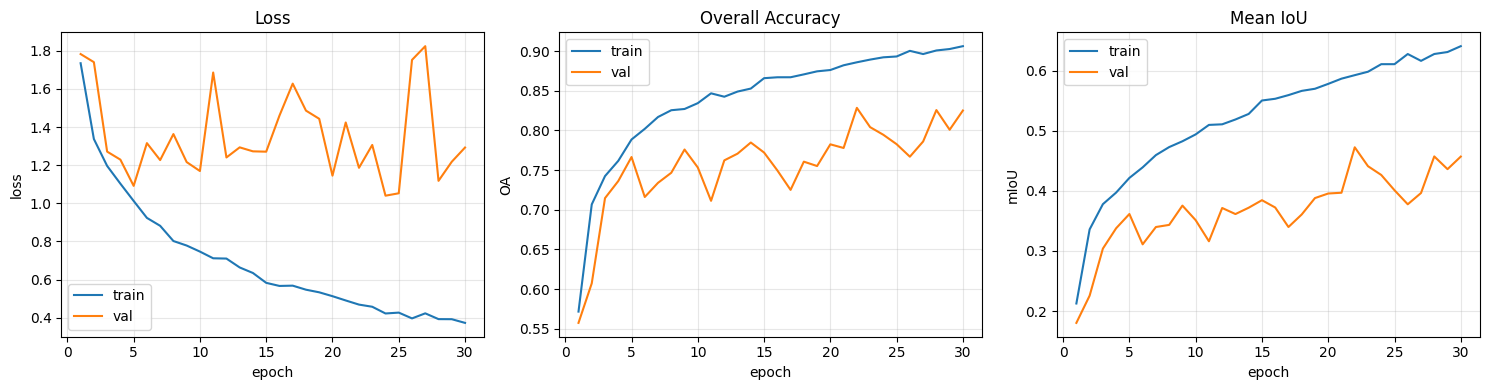

In [11]:
with open(MY_RESULTS / 'logs' / 'train_log.json') as f:
    log = json.load(f)

epochs  = [e['epoch'] for e in log]
tr_loss = [e['train']['loss'] for e in log]
vl_loss = [e['val']['loss'] for e in log]
tr_miou = [e['train']['miou'] for e in log]
vl_miou = [e['val']['miou'] for e in log]
tr_oa   = [e['train']['oa'] for e in log]
vl_oa   = [e['val']['oa'] for e in log]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs, tr_loss, label='train')
axes[0].plot(epochs, vl_loss, label='val')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, tr_oa, label='train')
axes[1].plot(epochs, vl_oa, label='val')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('OA')
axes[1].set_title('Overall Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(epochs, tr_miou, label='train')
axes[2].plot(epochs, vl_miou, label='val')
axes[2].set_xlabel('epoch')
axes[2].set_ylabel('mIoU')
axes[2].set_title('Mean IoU')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MY_RESULTS / 'figures' / 'training_curves.png', dpi=140)
plt.show()

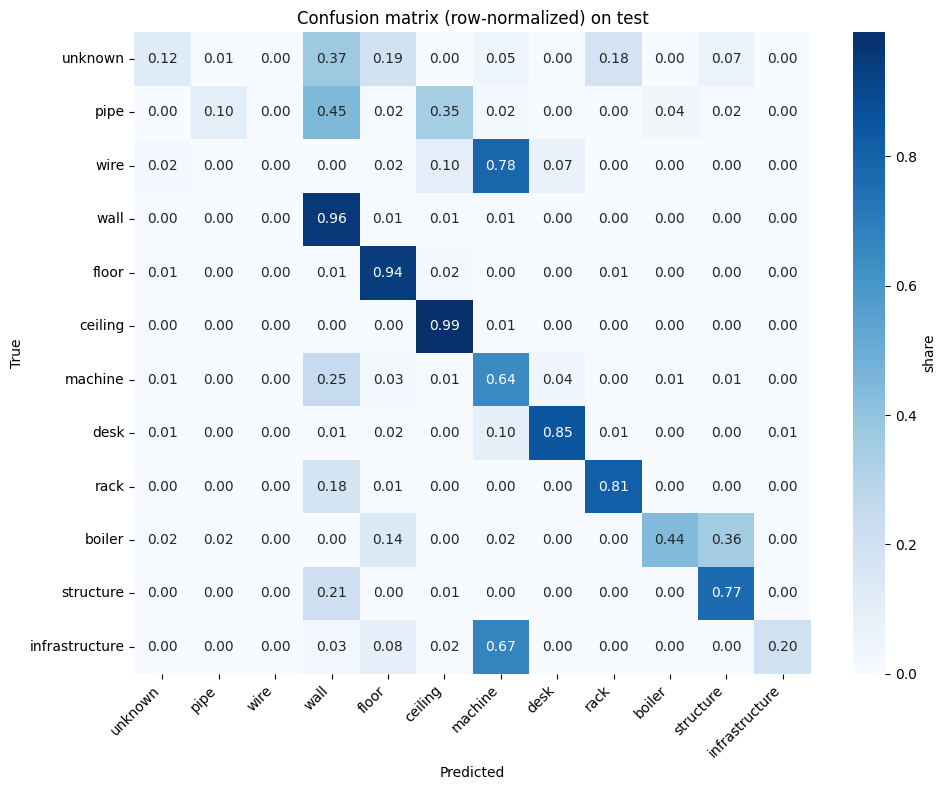

Saved confusion matrix to /content/drive/MyDrive/IS_project_results/results/confusion_matrix.npy


In [12]:
from sklearn.metrics import confusion_matrix

p = np.concatenate(all_preds)
l = np.concatenate(all_labels)
mask = l >= 0
cm = confusion_matrix(l[mask], p[mask], labels=list(range(N_CLASSES)))
cm_norm = cm.astype(np.float64) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

names = [NEW2NAME[i] for i in range(N_CLASSES)]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=names, yticklabels=names, cbar_kws={'label': 'share'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix (row-normalized) on test')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(MY_RESULTS / 'figures' / 'confusion_matrix.png', dpi=140)
plt.show()

np.save(MY_RESULTS / 'results' / 'confusion_matrix.npy', cm)
print(f"Saved confusion matrix to {MY_RESULTS / 'results' / 'confusion_matrix.npy'}")

         class      IoU       F1
       unknown 0.102126 0.185325
          pipe 0.096842 0.176584
          wire 0.000000 0.000000
          wall 0.600529 0.750413
         floor 0.896191 0.945254
       ceiling 0.930119 0.963795
       machine 0.505479 0.671519
          desk 0.772124 0.871411
          rack 0.725921 0.841199
        boiler 0.379070 0.549747
     structure 0.681636 0.810682
infrastructure 0.177185 0.301032


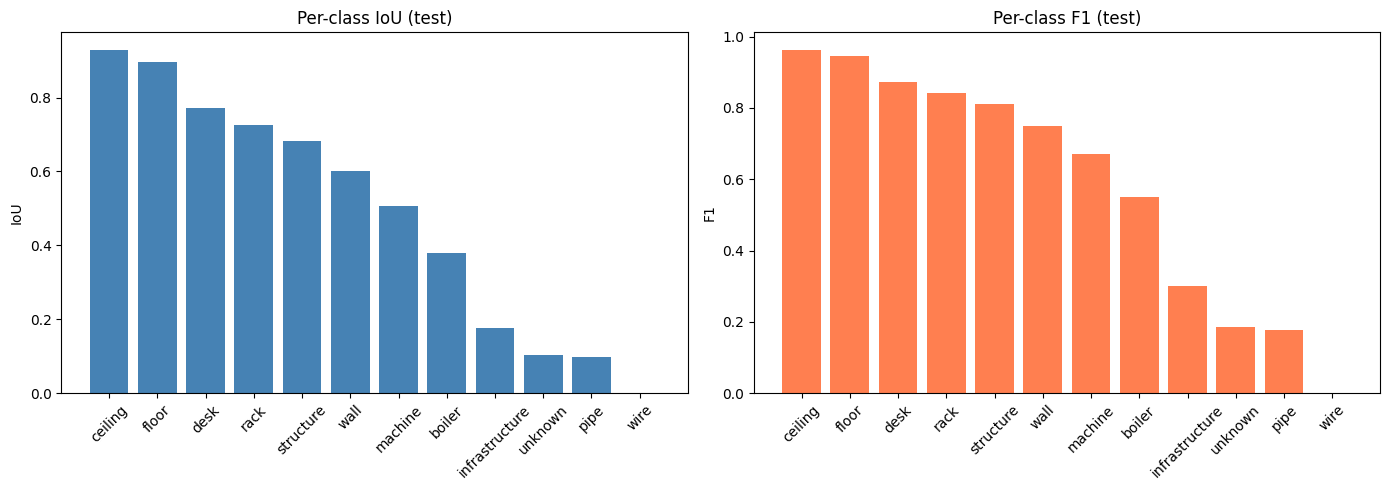


All results saved to: /content/drive/MyDrive/IS_project_results


In [13]:
rows = []
for i in range(N_CLASSES):
    rows.append({
        'class': NEW2NAME[i],
        'IoU': test_metrics['iou_per_class'][i],
        'F1':  test_metrics['f1_per_class'][i],
    })
df_class = pd.DataFrame(rows)
print(df_class.to_string(index=False))
df_class.to_csv(MY_RESULTS / 'results' / 'per_class_metrics.csv', index=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df_sorted = df_class.dropna().sort_values('IoU', ascending=False)

ax[0].bar(df_sorted['class'], df_sorted['IoU'], color='steelblue')
ax[0].set_ylabel('IoU')
ax[0].set_title('Per-class IoU (test)')
ax[0].tick_params(axis='x', rotation=45)

ax[1].bar(df_sorted['class'], df_sorted['F1'], color='coral')
ax[1].set_ylabel('F1')
ax[1].set_title('Per-class F1 (test)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(MY_RESULTS / 'figures' / 'per_class_metrics.png', dpi=140)
plt.show()

print(f"\nAll results saved to: {MY_RESULTS}")